In [1]:
pip install pandas numpy matplotlib scikit-learn xgboost joblib

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 13.2 MB/s eta 0:00:08
   - -------------------------------------- 4.5/101.7 MB 13.1 MB/s eta 0:00:08
   -- ------------------------------------- 7.3/101.7 MB 12.4 MB/s eta 0:00:08
   --- ------------------------------------ 10.0/101.7 MB 12.3 MB/s eta 0:00:08
   ---- ----------------------------------- 12.1/101.7 MB 11.5 MB/s eta 0:00:08
   ----- ---------------------------------- 13.9/101.7 MB 11.1 MB/s eta 0:00:08
   ------ --------------------------------- 16.0/101.7 MB 10.9 MB/s eta 0:00:08
   ------- -------------------------------- 18.4/101.7 MB 10.8 MB/s eta 0:00:08
   -------- ------------------------------- 20.4/101.7 MB 10.7 MB/s eta 0:00:08
   -------- ------------------------------- 22.5/101.7 MB 10.7 MB/s eta 0:00:08
   --------- ------------------------------ 24.6/101.7 MB 10.

import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import sqlite3
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

load dataset

In [2]:
df = pd.read_csv(
    "C:\Desktop\java internship\Predictive-Workforce-Availability-Model\data\Extended_Employee_Performance_and_Productivity_Data.csv"
)

print(df.head())

print(df.shape)

   Employee_ID        Department  Gender  Age   Job_Title  \
0            1                IT    Male   55  Specialist   
1            2           Finance    Male   29   Developer   
2            3           Finance    Male   55  Specialist   
3            4  Customer Support  Female   48     Analyst   
4            5       Engineering  Female   36     Analyst   

                    Hire_Date  Years_At_Company Education_Level  \
0  2022-01-19 08:03:05.556036                 2     High School   
1  2024-04-18 08:03:05.556036                 0     High School   
2  2015-10-26 08:03:05.556036                 8     High School   
3  2016-10-22 08:03:05.556036                 7        Bachelor   
4  2021-07-23 08:03:05.556036                 3        Bachelor   

   Performance_Score  Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0                  5          6750.0                   33                32   
1                  5          7500.0                   34               

In [3]:
print(df.columns)

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='object')


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  object 
 2   Gender                       100000 non-null  object 
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  object 
 5   Hire_Date                    100000 non-null  object 
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  object 
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  

In [5]:
print(df.isnull().sum())

Employee_ID                    0
Department                     0
Gender                         0
Age                            0
Job_Title                      0
Hire_Date                      0
Years_At_Company               0
Education_Level                0
Performance_Score              0
Monthly_Salary                 0
Work_Hours_Per_Week            0
Projects_Handled               0
Overtime_Hours                 0
Sick_Days                      0
Remote_Work_Frequency          0
Team_Size                      0
Training_Hours                 0
Promotions                     0
Employee_Satisfaction_Score    0
Resigned                       0
dtype: int64


Data Cleaning

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

In [7]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

FEATURE ENGINEERING

In [8]:
shifts = [
    'Morning',
    'Evening',
    'Night'
]

df['Shift_Type'] = np.random.choice(
    shifts,
    size=len(df)
)

In [9]:
complexity = [
    'Low',
    'Medium',
    'High'
]

df['Task_Complexity'] = np.random.choice(
    complexity,
    size=len(df)
)

In [10]:
df['Hire_Date'] = pd.to_datetime(
    df['Hire_Date']
)

In [11]:
df['Month'] = df['Hire_Date'].dt.month

In [12]:
def get_season(month):

    if month in [12,1,2]:
        return 'Winter'

    elif month in [3,4,5]:
        return 'Spring'

    elif month in [6,7,8]:
        return 'Summer'

    else:
        return 'Autumn'

In [13]:
df['Season'] = df['Month'].apply(
    get_season
)

In [14]:
df['Fatigue_Score'] = (

    (df['Overtime_Hours'] * 0.6)

    +

    (df['Work_Hours_Per_Week'] * 0.4)

)

In [15]:
df['Fatigue_Score'] = (

    (
        df['Fatigue_Score']
        -
        df['Fatigue_Score'].min()
    )

    /

    (
        df['Fatigue_Score'].max()
        -
        df['Fatigue_Score'].min()
    )

) * 9 + 1

In [16]:
print(

    df[[

        'Shift_Type',

        'Task_Complexity',

        'Season',

        'Fatigue_Score'

    ]].head()

)

  Shift_Type Task_Complexity  Season  Fatigue_Score
0    Evening            High  Winter       5.408163
1    Morning          Medium  Spring       3.877551
2    Evening          Medium  Autumn       2.959184
3      Night          Medium  Autumn       8.836735
4    Morning          Medium  Summer       7.306122


In [17]:
availability = []

for _, row in df.iterrows():

    probability = 0.92

    # High overtime
    if row['Overtime_Hours'] > 20:
        probability -= 0.15

    # Many sick days
    if row['Sick_Days'] > 10:
        probability -= 0.20

    # Low satisfaction
    if row['Employee_Satisfaction_Score'] < 2:
        probability -= 0.15

    # Poor performance
    if row['Performance_Score'] <= 2:
        probability -= 0.10

    # High fatigue
    if row['Fatigue_Score'] > 7:
        probability -= 0.15

    # Employee resigned
    if row['Resigned'] == True:
        probability -= 0.50

    probability = max(0.05, probability)

    availability.append(

        np.random.choice(

            [1,0],

            p=[
                probability,
                1 - probability
            ]
        )
    )

df['Availability'] = availability

In [18]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [19]:
X = df.drop(
    'Availability',
    axis=1
)

y = df['Availability']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [21]:
df.drop(
    ['Hire_Date'],
    axis=1,
    inplace=True
)

In [22]:
print(df.dtypes)

Employee_ID                      int64
Age                              int64
Years_At_Company                 int64
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                          bool
Month                            int32
Fatigue_Score                  float64
Availability                     int64
Department_Engineering            bool
Department_Finance                bool
Department_HR                     bool
Department_IT                     bool
Department_Legal                  bool
Department_Marketing              bool
Department_Operations             bool
Department_Sales         

In [23]:
print(df.columns)

Index(['Employee_ID', 'Age', 'Years_At_Company', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned', 'Month', 'Fatigue_Score', 'Availability',
       'Department_Engineering', 'Department_Finance', 'Department_HR',
       'Department_IT', 'Department_Legal', 'Department_Marketing',
       'Department_Operations', 'Department_Sales', 'Gender_Male',
       'Gender_Other', 'Job_Title_Consultant', 'Job_Title_Developer',
       'Job_Title_Engineer', 'Job_Title_Manager', 'Job_Title_Specialist',
       'Job_Title_Technician', 'Education_Level_High School',
       'Education_Level_Master', 'Education_Level_PhD', 'Shift_Type_Morning',
       'Shift_Type_Night', 'Task_Complexity_Low', 'Task_Complexity_Medium',
       'Season_Spring', 'Season_Summer', 'Season_Winter'],
      dtype='object')


In [24]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [25]:
X = df.drop(
    'Availability',
    axis=1
)

y = df['Availability']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [27]:
rf = RandomForestClassifier(

    n_estimators=100,

    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
drop_cols = [

    'Employee_ID',

    'Name',

    'Hire_Date',

    'Department',

    'Job_Title'

]

df.drop(
    drop_cols,
    axis=1,
    inplace=True,
    errors='ignore'
)

In [29]:
df.drop(
    'Availability',
    axis=1,
    inplace=True,
    errors='ignore'
)

In [30]:
availability = []

for _, row in df.iterrows():

    score = 100

    # Heavy overtime
    if row['Overtime_Hours'] > 15:
        score -= 25

    # Too many sick days
    if row['Sick_Days'] > 8:
        score -= 30

    # Low satisfaction
    if row['Employee_Satisfaction_Score'] < 3:
        score -= 20

    # Poor performance
    if row['Performance_Score'] < 3:
        score -= 15

    # High fatigue
    if row['Fatigue_Score'] > 7:
        score -= 20

    # Resigned employee
    if row['Resigned'] == True:
        score -= 60

    # Workload pressure
    if row['Projects_Handled'] > 8:
        score -= 10

    # Convert score into target
    if score >= 60:
        availability.append(1)
    else:
        availability.append(0)

df['Availability'] = availability

In [31]:
print(
    df['Availability'].value_counts()
)

Availability
0    66220
1    33780
Name: count, dtype: int64


In [32]:
important_features = [

    'Overtime_Hours',

    'Sick_Days',

    'Employee_Satisfaction_Score',

    'Performance_Score',

    'Work_Hours_Per_Week',

    'Projects_Handled',

    'Fatigue_Score'

]

X = df[important_features]

y = df['Availability']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [36]:
xgb_pred = xgb.predict(
    X_test
)

Accuracy

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    'XGBoost Accuracy:',
    accuracy
)

XGBoost Accuracy: 0.96315


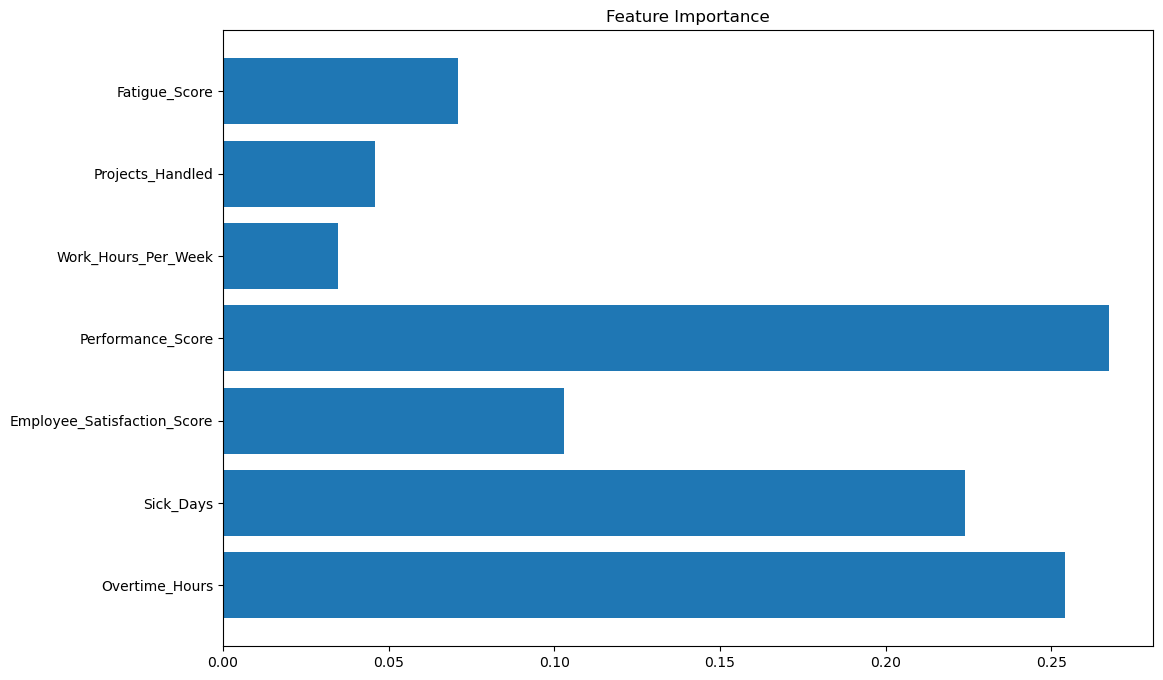

In [38]:
importance = xgb.feature_importances_

features = X.columns

plt.figure(figsize=(12,8))

plt.barh(
    features,
    importance
)

plt.title(
    'Feature Importance'
)

plt.show()

In [39]:
predictions = pd.DataFrame({

    'Actual': y_test,

    'Predicted': xgb_pred

})

In [40]:
predictions.to_csv(

    r"C:\Desktop\java internship\Predictive-Workforce-Availability-Model\outputs\predictions.csv",

    index=False
)

In [41]:
import sqlite3

conn = sqlite3.connect(

    r"C:\Desktop\java internship\Predictive-Workforce-Availability-Model\outputs\workforce.db"

)

df.to_sql(

    'workforce_predictions',

    conn,

    if_exists='replace',

    index=False
)

conn.close()

In [42]:
df.to_csv(

    r"C:\Desktop\java internship\Predictive-Workforce-Availability-Model\outputs\workforce_data.csv",

    index=False
)

In [43]:
print(df.dtypes)

Age                              int64
Years_At_Company                 int64
Performance_Score                int64
Monthly_Salary                 float64
Work_Hours_Per_Week              int64
Projects_Handled                 int64
Overtime_Hours                   int64
Sick_Days                        int64
Remote_Work_Frequency            int64
Team_Size                        int64
Training_Hours                   int64
Promotions                       int64
Employee_Satisfaction_Score    float64
Resigned                         int64
Month                            int32
Fatigue_Score                  float64
Department_Engineering           int64
Department_Finance               int64
Department_HR                    int64
Department_IT                    int64
Department_Legal                 int64
Department_Marketing             int64
Department_Operations            int64
Department_Sales                 int64
Gender_Male                      int64
Gender_Other             